In [1]:
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [2]:
class Ellipse_random_point_generator():
    """
    Represents a ellipitical volume within which neurons may be distributed.
    """
    def __init__(self, radius_x, radius_y, radius_z, encapsulation_x, encapsulation_y, stimulating_electrode_position, rotation_angle):
        self.radius_x = radius_x
        self.radius_y = radius_y
        self.radius_z = radius_z
        self.encapsulation_x = encapsulation_x
        self.encapsulation_y = encapsulation_y
        self.stimulating_electrode_position = stimulating_electrode_position
        self.rotation_angle = rotation_angle

    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the eclipse"""
        num_points = n

        #rotation angle of an ellipse defines its tilt relative to the standard x-axis
        self.rotation_angle = np.pi/2 - self.rotation_angle

        x_points = []
        y_points = []
        z_points = []


        # Generate a random point inside the sphere
        theta = np.random.uniform(0, 2 * np.pi, num_points) 
        phi = np.random.uniform(0, np.pi, num_points) 
        x_radius = self.radius_x*np.cbrt(np.random.uniform(0, 1, num_points))  
        y_radius = self.radius_y*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius_z*np.cbrt(np.random.uniform(0, 1, num_points))

        x = x_radius * np.sin(phi) * np.cos(theta)
        y = y_radius * np.sin(phi) * np.sin(theta)
        z = z_radius * np.cos(phi)+ self.stimulating_electrode_position[2]

        #rotate around the z axis
        x_points = x*np.cos(self.rotation_angle) - y*np.sin(self.rotation_angle)
        y_points = y*np.cos(self.rotation_angle) + x*np.sin(self.rotation_angle)
        z_points = z

        invalid_x = (x_points > -self.encapsulation_x) & (x_points < self.encapsulation_x)
        invalid_y = (y_points > -self.encapsulation_x) & (y_points < self.encapsulation_y)

        invalid = invalid_x & invalid_y

        while np.any(invalid):
            n = invalid.sum()
            # Generate a random point inside the sphere
            theta = np.random.uniform(0, 2 * np.pi)
            phi = np.random.uniform(0, np.pi)
            x_radius = self.radius_x*np.cbrt(np.random.uniform(0, 1))  # uniform volume
            y_radius = self.radius_y*np.cbrt(np.random.uniform(0, 1))

            x_new = x_radius * np.sin(phi) * np.cos(theta)
            y_new = y_radius * np.sin(phi) * np.sin(theta)

            #rotate around the z axis
            x_points[invalid] = x_new*np.cos(self.rotation_angle) - y_new*np.sin(self.rotation_angle)
            y_points[invalid] = y_new*np.cos(self.rotation_angle) + x_new*np.sin(self.rotation_angle)

            invalid_x = (x_points > -self.encapsulation_x) & (x_points < self.encapsulation_x)
            invalid_y = (y_points > -self.encapsulation_x) & (y_points < self.encapsulation_y)

            invalid = invalid_x & invalid_y

        points = np.column_stack((x_points, y_points, z_points))
        return points



In [3]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 100
rotation_angle = 0.610865
encapsulation_x = 1000
encapsulation_y= 1000
stimulating_electrode_position = np.array([0,0,0])

############ Setup the simulation##########
sim.setup(timestep=0.01)


###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
ellipse = Ellipse_random_point_generator(4176,3080,2961, encapsulation_x, encapsulation_y, stimulating_electrode_position, 0.610865)
cortical_space = ellipse.generate_positions(n)
STN_space = ellipse.generate_positions(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[:,0], cortical_space[:,1], cortical_space[:,2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[:,0], STN_space[:,1], np.ones(n)*500



sim.end()

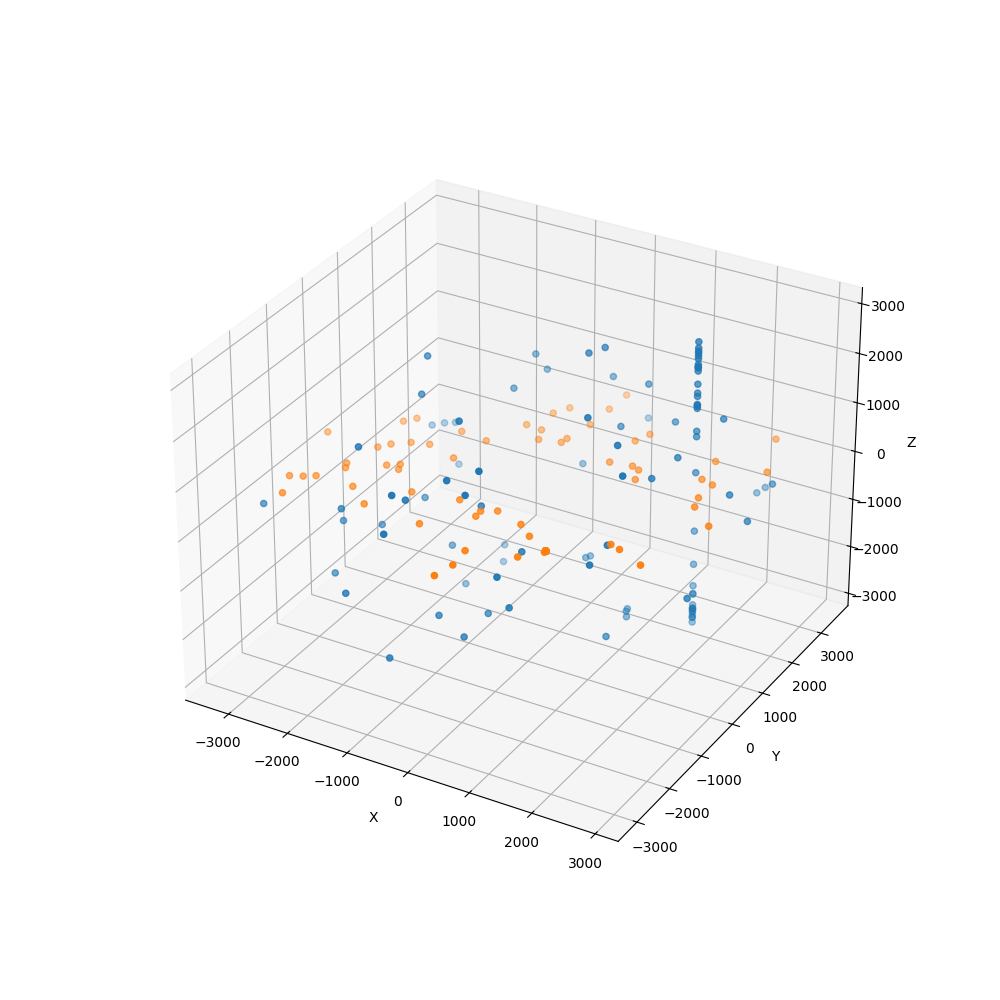

In [4]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx)

#interpolate the values for the stn neurons
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]
ax.scatter(x_points_clean_stn, y_points_clean_stn, z_points_clean_stn)

plt.show()